<a href="https://colab.research.google.com/github/badawyengineer/Parkinson_MachineModel/blob/main/Last_Parkinson_Model.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [9]:
# IMPORTANT: RUN THIS CELL IN ORDER TO IMPORT YOUR KAGGLE DATA SOURCES,
# THEN FEEL FREE TO DELETE THIS CELL.
# NOTE: THIS NOTEBOOK ENVIRONMENT DIFFERS FROM KAGGLE'S PYTHON
# ENVIRONMENT SO THERE MAY BE MISSING LIBRARIES USED BY YOUR
# NOTEBOOK.
import kagglehub
debasisdotcom_parkinson_disease_detection_path = kagglehub.dataset_download('debasisdotcom/parkinson-disease-detection')

print('Data source import complete.')


Using Colab cache for faster access to the 'parkinson-disease-detection' dataset.
Data source import complete.


In [10]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All"
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

/kaggle/input/parkinson-disease-detection/Parkinsson disease.csv


In [11]:
import numpy as np
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn import svm
from sklearn.metrics import accuracy_score

In [12]:
import seaborn as sns
import matplotlib.pyplot as plt

## Data Info

In [13]:
import os
df=pd.read_csv(os.path.join(debasisdotcom_parkinson_disease_detection_path, 'Parkinsson disease.csv'))
df.head()

,name,MDVP:Fo(Hz),MDVP:Fhi(Hz),MDVP:Flo(Hz),MDVP:Jitter(%),MDVP:Jitter(Abs),MDVP:RAP,MDVP:PPQ,Jitter:DDP,MDVP:Shimmer,...,Shimmer:DDA,NHR,HNR,status,RPDE,DFA,spread1,spread2,D2,PPE
0,phon_R01_S01_1,119.992,157.302,74.997,0.00784,0.00007,0.00370,0.00554,0.01109,0.04374,...,0.06545,0.02211,21.033,1,0.414783,0.815285,-4.813031,0.266482,2.301442,0.284654
1,phon_R01_S01_2,122.400,148.650,113.819,0.00968,0.00008,0.00465,0.00696,0.01394,0.06134,...,0.09403,0.01929,19.085,1,0.458359,0.819521,-4.075192,0.335590,2.486855,0.368674
2,phon_R01_S01_3,116.682,131.111,111.555,0.01050,0.00009,0.00544,0.00781,0.01633,0.05233,...,0.08270,0.01309,20.651,1,0.429895,0.825288,-4.443179,0.311173,2.342259,0.332634
3,phon_R01_S01_4,116.676,137.871,111.366,0.00997,0.00009,0.00502,0.00698,0.01505,0.05492,...,0.08771,0.01353,20.644,1,0.434969,0.819235,-4.117501,0.334147,2.405554,0.368975
4,phon_R01_S01_5,116.014,141.781,110.655,0.01284,0.00011,0.00655,0.00908,0.01966,0.06425,...,0.10470,0.01767,19.649,1,0.417356,0.823484,-3.747787,0.234513,2.332180,0.410335


In [14]:
import pandas as pd
import os

# Use the correct path from the kagglehub download
file_path = os.path.join(debasisdotcom_parkinson_disease_detection_path, 'Parkinsson disease.csv')
df_test = pd.read_csv(file_path)

# Preprocess the sample (remove name and status)
# Note: This requires the 'pipeline' variable from the training section to be defined
try:
    X_sample = df_test.drop(columns=['name', 'status'])
    sample = X_sample.iloc[0:1]

    # Make prediction using the trained pipeline
    prediction = pipeline.predict(sample)[0]
    prob = pipeline.predict_proba(sample)[0][1]

    print("Auto Test Prediction:", "Parkinson Detected" if prediction == 1 else "Healthy")
    print(f"Confidence: {prob:.4f}")
except NameError:
    print("Error: 'pipeline' is not defined. Please run the cell that defines and fits the pipeline first (e.g., cell E1l8tn7aEuh9).")

Error: 'pipeline' is not defined. Please run the cell that defines and fits the pipeline first (e.g., cell E1l8tn7aEuh9).


In [15]:
print(df.shape)
print(df.info())

(195, 24)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 195 entries, 0 to 194
Data columns (total 24 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   name              195 non-null    object 
 1   MDVP:Fo(Hz)       195 non-null    float64
 2   MDVP:Fhi(Hz)      195 non-null    float64
 3   MDVP:Flo(Hz)      195 non-null    float64
 4   MDVP:Jitter(%)    195 non-null    float64
 5   MDVP:Jitter(Abs)  195 non-null    float64
 6   MDVP:RAP          195 non-null    float64
 7   MDVP:PPQ          195 non-null    float64
 8   Jitter:DDP        195 non-null    float64
 9   MDVP:Shimmer      195 non-null    float64
 10  MDVP:Shimmer(dB)  195 non-null    float64
 11  Shimmer:APQ3      195 non-null    float64
 12  Shimmer:APQ5      195 non-null    float64
 13  MDVP:APQ          195 non-null    float64
 14  Shimmer:DDA       195 non-null    float64
 15  NHR               195 non-null    float64
 16  HNR               195 non-null    

In [16]:
df.isnull().sum()

,0
name,0
MDVP:Fo(Hz),0
MDVP:Fhi(Hz),0
MDVP:Flo(Hz),0
MDVP:Jitter(%),0
MDVP:Jitter(Abs),0
MDVP:RAP,0
MDVP:PPQ,0
Jitter:DDP,0
MDVP:Shimmer,0


In [17]:
df['status'] == 0

,status
0,False
1,False
2,False
3,False
4,False
...,...
190,True
191,True
192,True
193,True


In [19]:
# To test in the notebook, we use standard python instead of streamlit (st)
try:
    # Use the first row of X as sample data
    sample_data = X.iloc[0:1]

    # Use the trained pipeline to predict
    prediction = pipeline.predict(sample_data)[0]
    prob = pipeline.predict_proba(sample_data)[0][1]

    print(f"Test Sample Prediction: {'Parkinson Detected' if prediction == 1 else 'Healthy'}")
    print(f"Confidence: {prob:.4f}")
except NameError:
    print("Error: 'X' or 'pipeline' is not defined. Please run the data processing and model training cells first.")

Error: 'X' or 'pipeline' is not defined. Please run the data processing and model training cells first.


In [20]:
# Drop non-feature columns
# errors='ignore' prevents crashing if the columns were already dropped
X = df.drop(columns=['name', 'status'], errors='ignore')

# Take one row
sample = X.iloc[5]
",".join(map(str, sample.values))

'120.552,131.162,113.787,0.00968,8e-05,0.00463,0.0075,0.01388,0.04701,0.456,0.02328,0.03526,0.03243,0.06985,0.01222,21.378,0.415564,0.825069,-4.242867,0.299111,2.18756,0.357775'

In [21]:
parkinson_indices = df[df['status'] == 1].index
print(parkinson_indices)

Index([  0,   1,   2,   3,   4,   5,   6,   7,   8,   9,
       ...
       161, 162, 163, 164, 177, 178, 179, 180, 181, 182],
      dtype='int64', length=147)


In [22]:
healthy_indices = df[df['status'] == 0].index
print(healthy_indices)

Index([ 30,  31,  32,  33,  34,  35,  42,  43,  44,  45,  46,  47,  48,  49,
        50,  51,  52,  53,  60,  61,  62,  63,  64,  65, 165, 166, 167, 168,
       169, 170, 171, 172, 173, 174, 175, 176, 183, 184, 185, 186, 187, 188,
       189, 190, 191, 192, 193, 194],
      dtype='int64')


In [23]:
print("Parkinson range:", parkinson_indices.min(), "to", parkinson_indices.max())
print("Healthy range:", healthy_indices.min(), "to", healthy_indices.max())

Parkinson range: 0 to 182
Healthy range: 30 to 194


In [24]:
df['status'].value_counts(normalize=True)

,proportion
status,
1,0.753846
0,0.246154


1 --> positive parkinson

0 --> Healthy

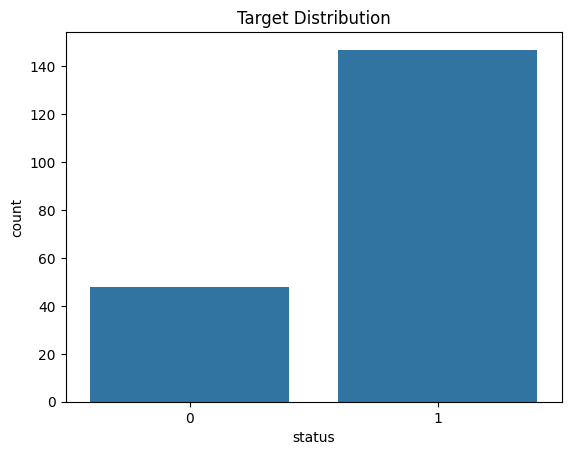

In [25]:
sns.countplot(x='status', data=df)
plt.title("Target Distribution")
plt.show()

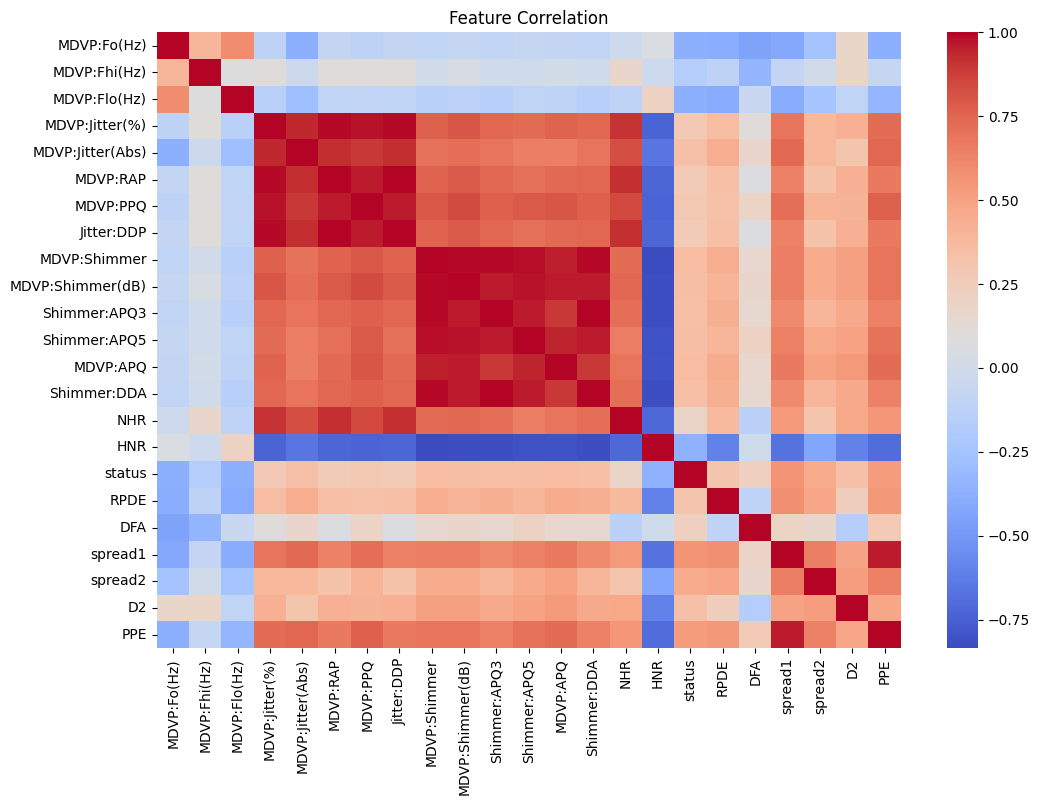

In [26]:
plt.figure(figsize=(12,8))
sns.heatmap(df.drop('name', axis=1).corr(), cmap='coolwarm')
plt.title("Feature Correlation")
plt.show()

## Preproccesing

In [27]:
df = df.drop(columns=['name'], errors='ignore')

In [28]:
#split fet & Trg
X = df.drop(columns=['status'])
y = df['status']

In [29]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

In [30]:
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.svm import SVC

pipeline = Pipeline([
    ('scaler', StandardScaler()),
    ('model', SVC(probability=True))
])

In [31]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LogisticRegression

models = {
    "SVM": SVC(probability=True),
    "RandomForest": RandomForestClassifier(),
    "LogisticRegression": LogisticRegression(max_iter=1000)
}

Multiple Model_selection

In [32]:
#cross validation
from sklearn.model_selection import cross_val_score

for name, model in models.items():
    pipe = Pipeline([
        ('scaler', StandardScaler()),
        ('model', model)
    ])

    scores = cross_val_score(pipe, X, y, cv=5, scoring='f1')
    print(f"{name}: {scores.mean():.4f}")

SVM: 0.9085
RandomForest: 0.8669
LogisticRegression: 0.8801


In [33]:
#evaluation
from sklearn.metrics import classification_report, confusion_matrix, roc_auc_score

pipeline.fit(X_train, y_train)
y_pred = pipeline.predict(X_test)

print(confusion_matrix(y_test, y_pred))
print(classification_report(y_test, y_pred))

[[ 7  3]
 [ 0 29]]
              precision    recall  f1-score   support

           0       1.00      0.70      0.82        10
           1       0.91      1.00      0.95        29

    accuracy                           0.92        39
   macro avg       0.95      0.85      0.89        39
weighted avg       0.93      0.92      0.92        39



In [34]:
#hyper tunning
from sklearn.model_selection import GridSearchCV

param_grid = {
    'model__C': [0.1, 1, 10],
    'model__kernel': ['linear', 'rbf']
}

grid = GridSearchCV(pipeline, param_grid, cv=5, scoring='f1')
grid.fit(X_train, y_train)

print(grid.best_params_)

{'model__C': 10, 'model__kernel': 'rbf'}


/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but StandardScaler was fitted with feature names
  warnings.warn(


  0%|          | 0/39 [00:00<?, ?it/s]

/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but StandardScaler was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but StandardScaler was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but StandardScaler was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but StandardScaler was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but StandardScaler was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/ut

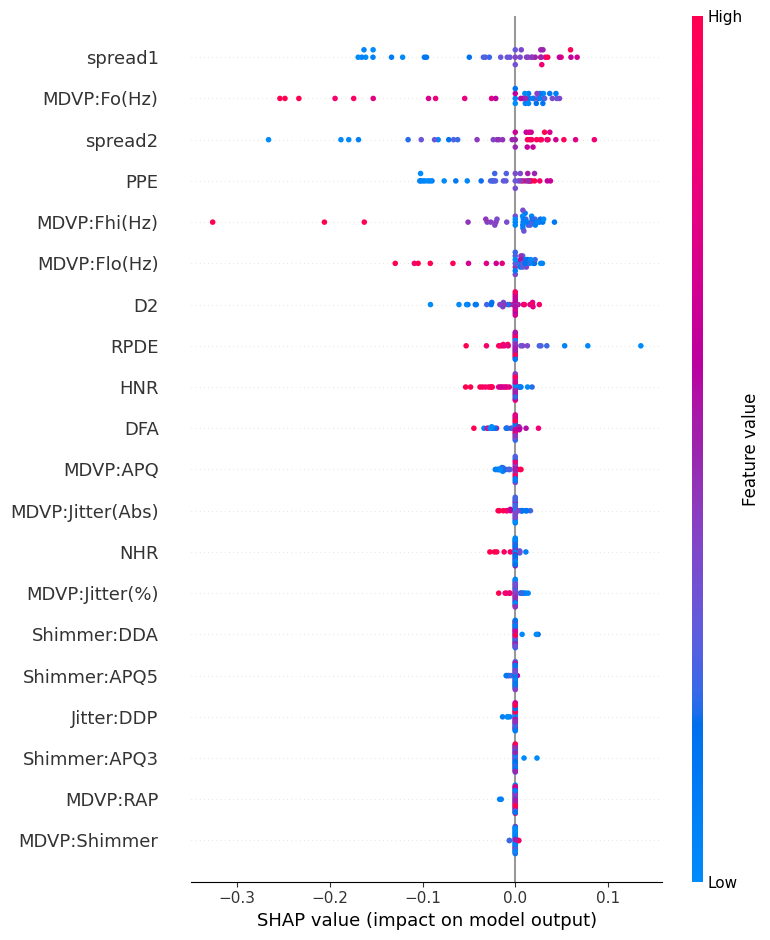

In [35]:
import shap
import numpy as np

# Wrap prediction function
predict_fn = lambda x: pipeline.predict_proba(x)

# Summarize background for speed
background = shap.kmeans(X_train, 5)
explainer = shap.KernelExplainer(predict_fn, background)

# Calculate SHAP values
shap_values = explainer.shap_values(X_test)

# Handle different possible return formats from KernelExplainer
if isinstance(shap_values, list):
    # If list, take class 1
    shap_val_array = np.array(shap_values[1])
elif len(shap_values.shape) == 3:
    # If 3D array (samples, features, classes), take class 1
    shap_val_array = shap_values[:, :, 1]
else:
    shap_val_array = np.array(shap_values)

features_array = X_test.values

# Final check to ensure alignment
if shap_val_array.shape == features_array.shape:
    shap.summary_plot(shap_val_array, features_array, feature_names=X_test.columns)
else:
    print(f"Shape mismatch: SHAP {shap_val_array.shape} vs Features {features_array.shape}")

In [36]:
!pip install streamlit pyngrok

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 9.1/9.1 MB 76.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 6.9/6.9 MB 89.8 MB/s eta 0:00:00


In [38]:
import joblib
import os

# Create the models directory if it doesn't exist
os.makedirs("models", exist_ok=True)

# Based on your previous cells, the model is stored in 'pipeline'
joblib.dump(pipeline, "models/parkinson_model.pkl")
print("Model saved successfully in 'models/parkinson_model.pkl'")

Model saved successfully in 'models/parkinson_model.pkl'


In [39]:
%%writefile app.py
import streamlit as st
import numpy as np
import joblib

# Load model (make sure you saved it before)
model = joblib.load("models/parkinson_model.pkl")

st.title("Parkinson Detection AI")

st.write("Enter patient features below:")

# Example input (simplified for now)
input_data = st.text_area("Input Features (comma separated)")

if st.button("Predict"):
    try:
        data = np.array([float(i) for i in input_data.split(",")]).reshape(1, -1)

        prediction = model.predict(data)[0]
        prob = model.predict_proba(data)[0][1]

        if prediction == 1:
            st.error(f"⚠️ Parkinson Detected (Confidence: {prob:.2f})")
        else:
            st.success(f"✅ Healthy (Confidence: {1 - prob:.2f})")

    except:
        st.warning("❗ Please enter valid numeric values")

Writing app.py


In [40]:
from pyngrok import ngrok

# Replace 'YOUR_AUTHTOKEN_HERE' with the token from https://dashboard.ngrok.com/get-started/your-authtoken
ngrok.set_auth_token("39m0BpLcYn3xhAA07UnHwICK4Jt_5sh59kjp91bM1ej4erbZr")

try:
    public_url = ngrok.connect(8501)
    print(f"Public URL: {public_url}")
except Exception as e:
    print(f"Error: {e}\n\nNote: You must set your ngrok authtoken above to fix this.")

Public URL: NgrokTunnel: "https://shaniqua-nondiffused-austerely.ngrok-free.dev" -> "http://localhost:8501"


In [ ]:
!streamlit run app.py &>/content/logs.txt &